In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
import cmocean

In [3]:
plt.style.use("~/nice.mplstyle")

In [3]:
hrrr = xr.open_zarr(
    "/pscratch/sd/t/timothys/nested-eagle/case-studies/la-fires/hrrr.forecasts.zarr"
)

In [4]:
rmse = xr.open_dataset(
    "/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-testing/spatial-metrics-vs-gfs-only/spatial.rmse.nested-globalvglobal.fc1vfc2.nc",
)

mae = xr.open_dataset(
    "/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-testing/spatial-metrics-vs-gfs-only/spatial.mae.nested-globalvglobal.fc1vfc2.nc",
)

rmse = rmse.sel(
    longitude=slice(225, 300),
    latitude=slice(52, 22),
)

mae = mae.sel(
    longitude=slice(225, 300),
    latitude=slice(52, 22),
)

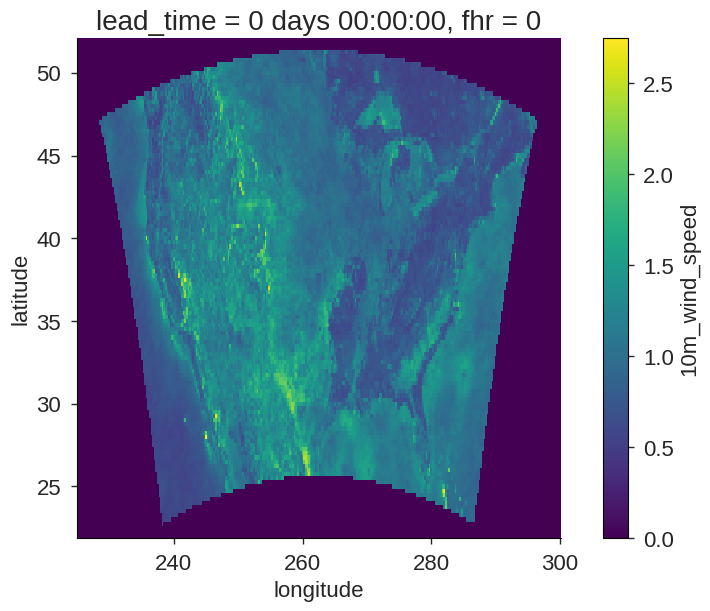

In [5]:
rmse["10m_wind_speed"].isel(fhr=0).plot()

In [6]:
rmseobs = xr.open_dataset(
    "/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-testing/spatial-obs-metrics/spatial.rmse.convobs.nested-lam.nc",
)[["2m_temperature","10m_wind_speed"]].sel(fhr=slice(24)) 



In [22]:
metric = "rmse"
nested = xr.open_dataset(
    f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-testing/spatial-obs-metrics/spatial.{metric}.convobs.nested-lam.nc",
)[["2m_temperature","10m_wind_speed"]].sel(fhr=slice(24)) 
glogle = xr.open_dataset(
    f"/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-only/stage1c/inference-testing/spatial-obs-metrics/spatial.{metric}.convobs.global.nc",
)[["2m_temperature","10m_wind_speed"]].sel(fhr=slice(24)) 

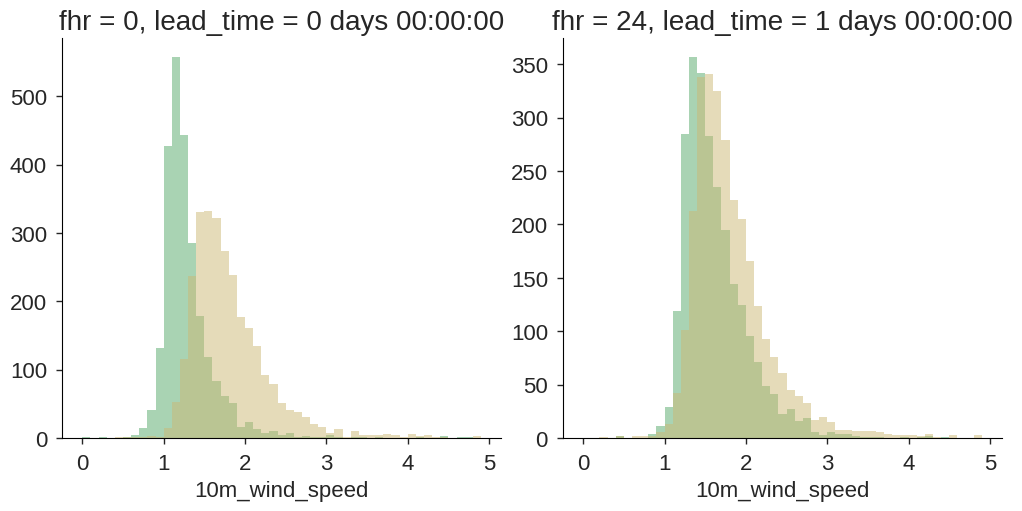

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
varname = "10m_wind_speed"

for xds, color in zip([nested, glogle], ["C0", "C5"]):
    for fhr, ax in zip([0, 24], axs):
        plotme = xds[varname].sel(fhr=fhr)
        #plotme = np.log(plotme)
        plotme.plot.hist(
            #bins=np.log(np.arange(50)/10),
            bins=np.arange(50)/10,
            ax=ax,
            color=color,
            alpha=.5,
        ) 
    

/tmp/ipykernel_1043194/2962856987.py:9: RuntimeWarning: divide by zero encountered in log
  bins=np.log(np.arange(50)/10),
/global/homes/t/timothys/.conda/envs/eagle/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7168: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)
/tmp/ipykernel_1043194/2962856987.py:9: RuntimeWarning: divide by zero encountered in log
  bins=np.log(np.arange(50)/10),
/global/homes/t/timothys/.conda/envs/eagle/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7168: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)
/tmp/ipykernel_1043194/2962856987.py:9: RuntimeWarning: divide by zero encountered in log
  bins=np.log(np.arange(50)/10),
/global/homes/t/timothys/.conda/envs/eagle/lib/python3.12/site-packages/matplotlib/axes/_axes.py:7168: RuntimeWarning: invalid value encountered in multiply
  boffset = -0.5 * dr * totwidth * (1 - 1 / nx)
/tmp/ipykernel_1

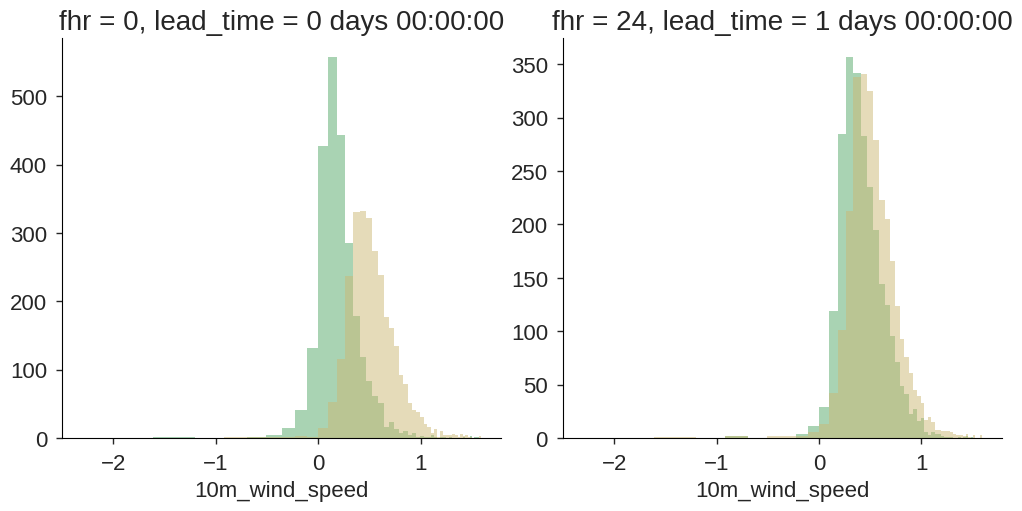

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
varname = "10m_wind_speed"

for xds, color in zip([nested, glogle], ["C0", "C5"]):
    for fhr, ax in zip([0, 24], axs):
        plotme = xds[varname].sel(fhr=fhr)
        plotme = np.log(plotme)
        plotme.plot.hist(
            bins=np.log(np.arange(50)/10),
            #bins=np.arange(50)/10,
            ax=ax,
            color=color,
            alpha=.5,
        ) 
    

In [14]:

foo = xr.open_dataset(
    "/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-only/stage1c/inference-testing/spatial-obs-metrics/spatial.rmse.convobs.global.nc",
)[["2m_temperature","10m_wind_speed"]].sel(fhr=slice(24)) 

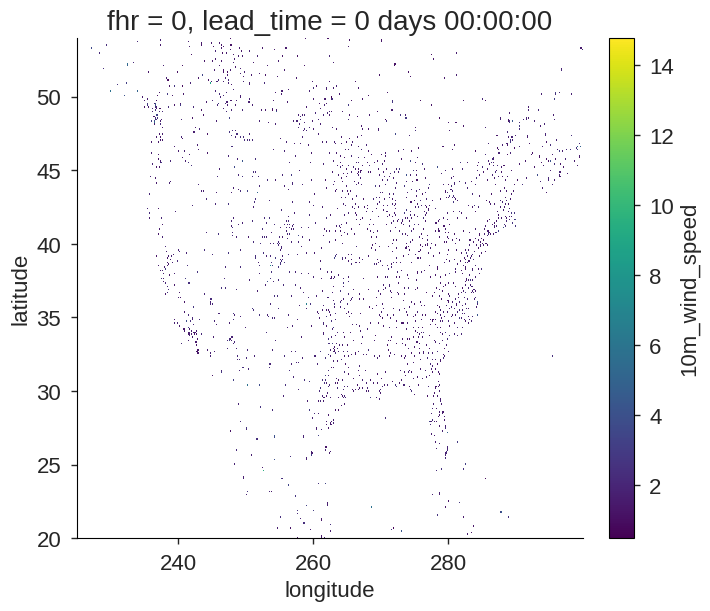

In [15]:
foo["10m_wind_speed"].sel(fhr=0).plot()

In [3]:
topo = xr.open_dataset("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/production/gfs-hrrr/stage1c/inference-testing/spatial-obs-metrics/orography_and_gradient.nc")

In [4]:
native = xr.open_zarr("/pscratch/sd/t/timothys/nested-eagle/0.25deg-06km/data/native/hrrr.zarr/")

In [5]:
native

<xarray.Dataset> Size: 274MB
Dimensions:     (t0: 8, y: 1059, x: 1799, fhr: 1)
Coordinates:
  * t0          (t0) datetime64[ns] 64B 2024-02-01 ... 2024-02-02T18:00:00
  * y           (y) int64 8kB 0 1 2 3 4 5 6 ... 1053 1054 1055 1056 1057 1058
  * x           (x) int64 14kB 0 1 2 3 4 5 6 ... 1793 1794 1795 1796 1797 1798
  * fhr         (fhr) int64 8B 0
    latitude    (y, x) float64 15MB dask.array<chunksize=(133, 450), meta=np.ndarray>
    lead_time   (fhr) timedelta64[ns] 8B dask.array<chunksize=(1,), meta=np.ndarray>
    longitude   (y, x) float64 15MB dask.array<chunksize=(133, 450), meta=np.ndarray>
    valid_time  (t0, fhr) datetime64[s] 64B dask.array<chunksize=(8, 1), meta=np.ndarray>
Data variables:
    lsm         (t0, y, x) float32 61MB dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    orog        (t0, y, x) float32 61MB dask.array<chunksize=(1, 1059, 1799), meta=np.ndarray>
    t_surface   (t0, fhr, y, x) float32 61MB dask.array<chunksize=(1, 1, 1059, 1799), meta=np.ndarray>
    vgtyp       (t0, fhr, y, x) float32 61MB dask.array<chunksize=(1, 1, 1059, 1799), meta=np.ndarray>
Attributes:
    latest_write_timestamp:  2026-06-05T04:20:51
    recipe:                  {'directories': {'cache': '${SCRATCH}/nested-eag...

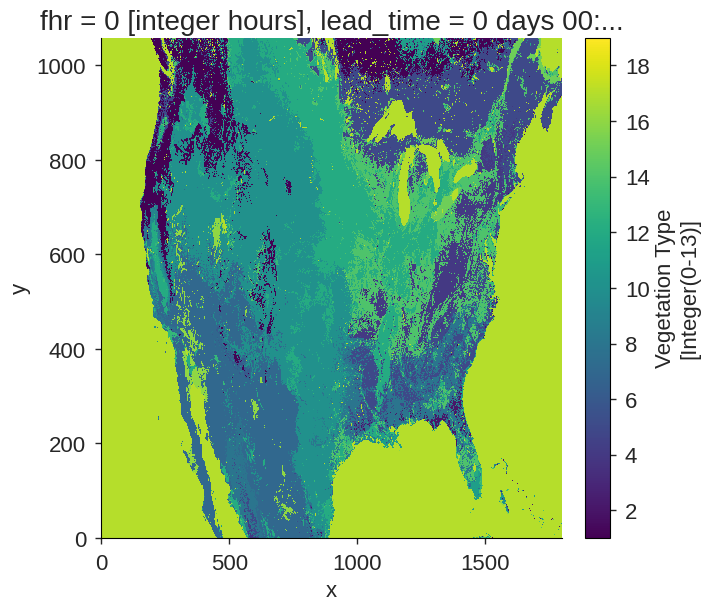

In [14]:
native.vgtyp.isel(t0=3).plot()

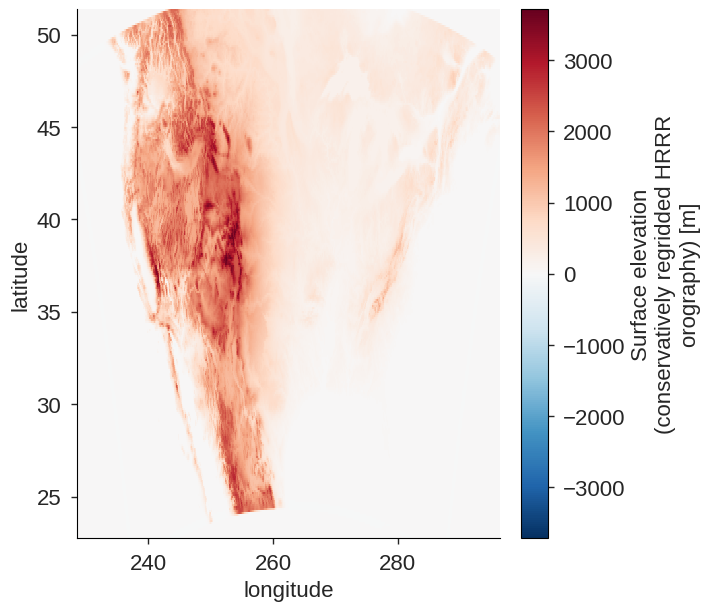

In [4]:
topo.orography.plot()

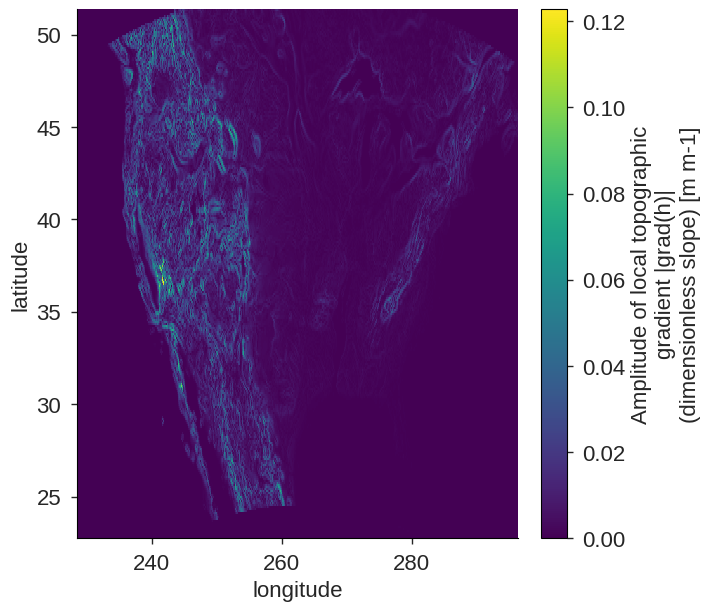

In [5]:
topo.grad_mag.plot()

In [6]:
topo.latitude.max(), topo.latitude.min()

(<xarray.DataArray 'latitude' ()> Size: 8B
 array(51.31428911),
 <xarray.DataArray 'latitude' ()> Size: 8B
 array(22.80228911))

In [7]:
topo.longitude.max(), topo.longitude.min()

(<xarray.DataArray 'longitude' ()> Size: 8B
 array(296.35738538),
 <xarray.DataArray 'longitude' ()> Size: 8B
 array(228.53338538))

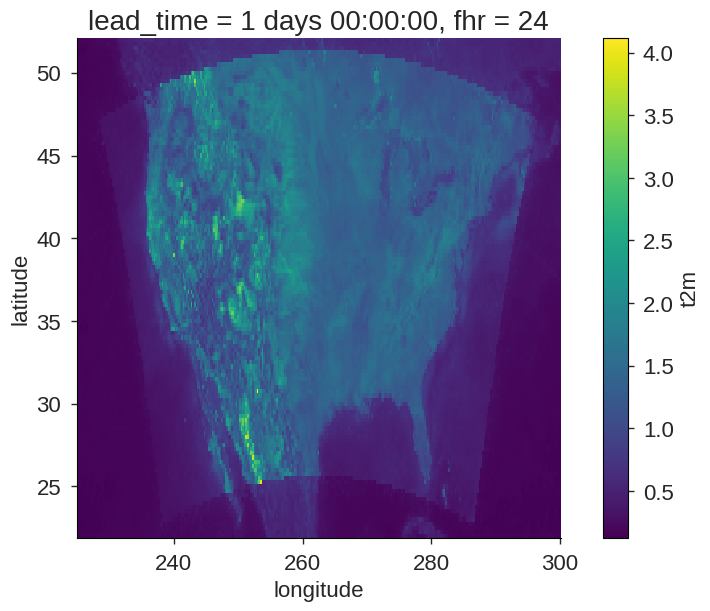

In [23]:
rmse.t2m.sel(fhr=24).plot()

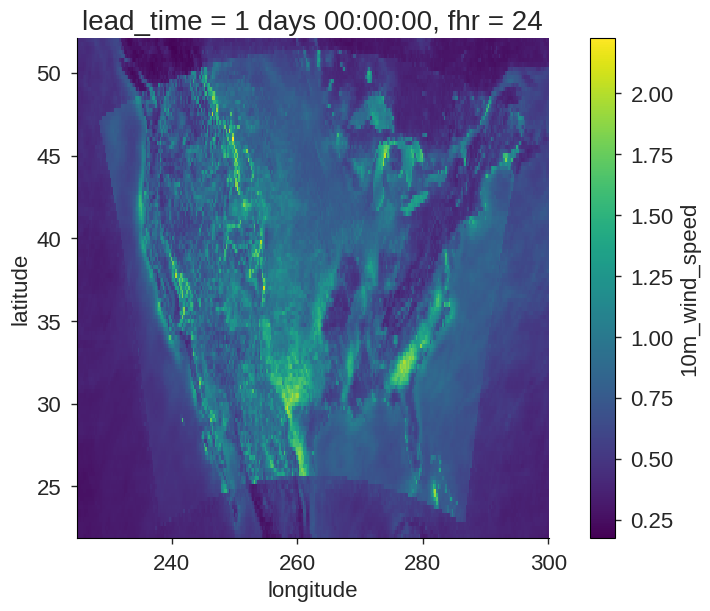

In [25]:
rmse["10m_wind_speed"].sel(fhr=24).plot()